# Étape 4 (J4) : Clustering des pays et restitution opérationnelle

Dans cette dernière étape, nous allons :
1. Réaliser une classification non supervisée (**K-Means**) pour regrouper les pays selon leur profil alimentaire et nutritionnel.
2. Déterminer le nombre optimal de clusters ($k$) à l'aide de la méthode du coude (Elbow Method) et du score de silhouette.
3. Interpréter chaque cluster à l'aide de variables descriptives clés et leur attribuer un nom métier.
4. Formuler des recommandations opérationnelles pour la FAO.

## 1.Importation des bibliothèques et préparation des données

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
%matplotlib inline
from sklearn.cluster import KMeans

In [110]:
df_global = pd.read_csv('dataset_global_fao.csv')
print(df_global.shape)
df_global.head()

(171, 9)


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850
4,Allemagne,79,2461.0,1042.0,82727,NaN,3503.0,82727000,NaN


In [111]:
df = pd.read_csv('dataset_global_fao_impute.csv')  
print(df.shape)
df.head(5)

(171, 11)


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Part_animaux_pct,Part_vegetaux_pct
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554,10.349784,89.650216
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482,16.125828,83.874172
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183,30.897114,69.102886
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850,11.478895,88.521105
4,Angola,7,2221.0,253.0,21472,8.1,2474.0,21472000,37.723547,10.226354,89.773646


In [112]:
print(df.columns.tolist())

['Zone', 'Code zone', 'Kcal_vegetaux', 'Kcal_animaux', 'Population_milliers', 'SousAlimentation_millions', 'Disponibilite_calorique_totale_kcal', 'Population_totale', 'Taux_sousnutrition_pct', 'Part_animaux_pct', 'Part_vegetaux_pct']


In [120]:
X_coude = df[[
    'Disponibilite_calorique_totale_kcal',
    'Part_vegetaux_pct',
    'Part_animaux_pct',
    'Taux_sousnutrition_pct',
]]

scaler = StandardScaler()
X_coude_scaled = scaler.fit_transform(X_coude)

print(f"Nombre de pays retenus pour le clustering : {X_coude_scaled.shape[0]}")

Nombre de pays retenus pour le clustering : 171


## 2.Détermination de $k$ (Méthode du coude et Score de Silhouette)

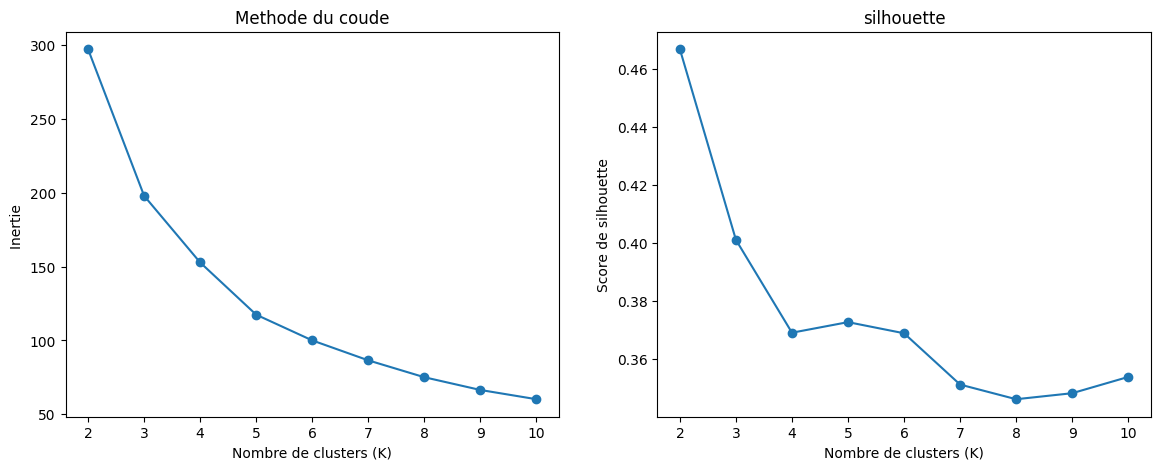

In [114]:
# Test de plusieurs valeurs de k (de 2 à 10)
inerties = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = km.fit_predict(X_coude_scaled)
  inerties.append(km.inertia_)
  silhouettes.append(silhouette_score(X_coude_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range,inerties, marker="o")
axes[0].set_xlabel("Nombre de clusters (K)")
axes[0].set_ylabel("Inertie ")
axes[0].set_title("Methode du coude")

axes[1].plot(K_range,silhouettes, marker="o")
axes[1].set_xlabel("Nombre de clusters (K)")
axes[1].set_ylabel("Score de silhouette")
axes[1].set_title("silhouette")

plt.show()

In [115]:
print(f"\nMeilleur K selon silhouette : {list(K_range)[silhouettes.index(max(silhouettes))]}")


Meilleur K selon silhouette : 2


## 3.Entraînement du modèle K-Means final

In [153]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_coude_scaled)
print(f'total clusters: {len(df['Cluster'].unique())}')
print(df['Cluster'].value_counts().sort_index())

total clusters: 5
Cluster
0    28
1    43
2    33
3    41
4    26
Name: count, dtype: int64


In [148]:
for c in sorted(df['Cluster'].unique()):
    print(f"--- Cluster {c} ---")
    print(df[df['Cluster'] == c]['Zone'].sample(2, random_state=42).to_string(index=False))
  

--- Cluster 0 ---
             Libéria
Sao Tomé-et-Principe
--- Cluster 1 ---
Saint-Vincent-et-les Grenadines
            Émirats arabes unis
--- Cluster 2 ---
Sainte-Lucie
    Viet Nam
--- Cluster 3 ---
Lituanie
Finlande
--- Cluster 4 ---
    Ghana
Nicaragua


In [149]:
df[['Zone','Cluster']].head()

,Zone,Cluster
0,Afghanistan,0
1,Afrique du Sud,1
2,Albanie,3
3,Algérie,1
4,Angola,0


## 4.Interprétation des clusters

In [137]:
cluster_profil = df.groupby('Cluster')[[
    'Disponibilite_calorique_totale_kcal',
    'Taux_sousnutrition_pct',
    'Part_animaux_pct',
    'Part_vegetaux_pct'
]].mean().round(1)

cluster_profil['Nb_pays'] = df['Cluster'].value_counts()
cluster_profil.sort_values('Cluster')

,Disponibilite_calorique_totale_kcal,Taux_sousnutrition_pct,Part_animaux_pct,Part_vegetaux_pct,Nb_pays
Cluster,,,,,
0,2206.4,32.4,8.4,91.6,28
1,3025.0,6.4,16.1,83.9,43
2,2699.6,10.5,25.1,74.9,33
3,3363.2,0.4,29.3,70.7,41
4,2593.6,14.4,7.5,92.5,26


### Interprétation et Profils des Clusters Identifiés :

* **Cluster 0 : « Pays en insécurité alimentaire chronique »**
  * *Caractéristiques* : Disponibilité calorique la plus faible (2206 kcal/j), taux de sous-nutrition le plus élevé (32,4 %), alimentation ultra-dominée par les végétaux (91,6 %, seulement 8,4 % d'origine animale). 28 pays.


* **Cluster 1 : « Pays en sécurité alimentaire équilibrée »**
  * *Caractéristiques* : Bonne disponibilité calorique (3025 kcal/j), sous-nutrition faible (6,4 %), équilibre modéré entre apports végétaux et animaux (16,1 % animal). 43 pays.

* **Cluster 2 : « Pays en transition nutritionnelle »**
  * *Caractéristiques* : Disponibilité calorique intermédiaire (2700 kcal/j), sous-nutrition modérée (10,5 %), diversification progressive de l'alimentation (25,1 % de part animale). 33 pays.

* **Cluster 3 : « Pays industrialisés à surconsommation calorique »**
  * *Caractéristiques* : Disponibilité calorique la plus élevée (3363 kcal/j), part animale la plus élevée (29,3 %), sous-nutrition résiduelle quasi nulle (0,4 %). 41 pays.

* **Cluster 4 : « Pays à disponibilité alimentaire limitée, dépendance végétale extrême »**
  * *Caractéristiques* : Disponibilité calorique légèrement supérieure au Cluster 0 (2594 kcal/j) mais part animale la plus faible de tous les clusters (7,5 %) et sous-nutrition encore marquée (14,4 %) — un déficit davantage lié au volume calorique disponible qu'à la composition du régime. 26 pays.



## Restitution et Recommandations Opérationnelles pour la FAO

À l'issue de cette analyse globale et du clustering des profils alimentaires mondiaux, deux recommandations stratégiques majeures sont formulées à destination de la FAO :

1. **Ciblage géographique de l'aide d'urgence (Cluster 0)** : 
   Les pays regroupés dans le cluster identifié comme vulnérable souffrent d'un double déficit (apport calorique insuffisant et carence en protéines animales). Les programmes d'aide alimentaire de la FAO doivent y être prioritairement concentrés, en soutenant structurellement la production locale de cultures vivrières résilientes et l'accès aux sources de protéines.

2. **Prévention des risques liés à la surconsommation (Cluster 3)** :
   À l'opposé du profil précédents, les pays de ce cluster affichent une disponibilité calorique et une part de protéines animales parmi les plus élevées de l'échantillon. L'enjeu de sécurité alimentaire y a basculé vers un risque inverse : surpoids, obésité et maladies non transmissibles liées à une alimentation trop calorique et trop riche en produits d'origine animale. La FAO pourrait orienter ses recommandations vers une meilleure information nutritionnelle du public et un encouragement à la modération de la consommation de produits animaux.